# Modular Human Data Loader Demo

This notebook demonstrates the split human data loaders in `ar_analysis.data_loader.human`. The legacy `ar_analysis.data_loader.human_data` module remains available, but new analysis code should import from the modular package.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if path.name == "abstract_reasoning" and (path / "analysis").exists():
            return path
    raise FileNotFoundError("Could not locate the abstract_reasoning repo root.")


ROOT = find_repo_root()
ANALYSIS_DIR = ROOT / "analysis"
SRC_DIR = ANALYSIS_DIR / "src"

for path in [SRC_DIR, ANALYSIS_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".temp/matplotlib"))

ROOT

PosixPath('/Users/chris/Documents/PhD-Local/abstract_reasoning')

In [2]:
import pandas as pd
from IPython.display import display
from box import Box
import matplotlib.pyplot as plt
import numpy as np
import mne

from ar_analysis.analysis_config import Config as c
from ar_analysis.data_loader.human import (
    HumanDataClass,
    HumanSessData,
    HumanSubjData,
    HumanGroupData,
)
from ar_analysis.utils.analysis_utils import list_contents, xdir, read_file, save_pickle
from ar_analysis.analysis_plotting import plot_erp

print("Loaded modular human classes from ar_analysis.data_loader.human")
print(HumanSessData, HumanSubjData, HumanGroupData, sep="\n")

Loaded modular human classes from ar_analysis.data_loader.human
<class 'ar_analysis.data_loader.human.session.HumanSessData'>
<class 'ar_analysis.data_loader.human.subject.HumanSubjData'>
<class 'ar_analysis.data_loader.human.group.HumanGroupData'>


## Data Directories

The cell below tries your usual external data locations and falls back to the last configured path if the drive is not mounted. Override these paths manually if needed.

In [4]:
DATA_ROOT_CANDIDATES = [
    Path(os.environ["ABSTRACT_REASONING_DATA_ROOT"])
    if "ABSTRACT_REASONING_DATA_ROOT" in os.environ
    else None,
    Path("/Volumes/SSD-512Go/PhD Data/experiment1/data"),
    Path("/Volumes/Realtek 1Tb/PhD Data/experiment1/data"),
]
DATA_ROOT_CANDIDATES = [path for path in DATA_ROOT_CANDIDATES if path is not None]
DATA_ROOT = next(
    (path for path in DATA_ROOT_CANDIDATES if path.exists()), DATA_ROOT_CANDIDATES[-1]
)

HUMAN_DATA_DIR_CANDIDATES = [
    DATA_ROOT / "Lab/raw-BIDS3",
    DATA_ROOT / "Lab/raw-BIDS",
    DATA_ROOT / "Lab/raw",
]
HUMAN_DATA_DIR = next(
    (path for path in HUMAN_DATA_DIR_CANDIDATES if path.exists()),
    HUMAN_DATA_DIR_CANDIDATES[0],
)
PREPROCESSED_DIR = DATA_ROOT / "Lab/preprocessed"
EXPORT_DIR = DATA_ROOT / "Lab/analyzed"

print(f"DATA_ROOT:        {DATA_ROOT}  exists={DATA_ROOT.exists()}")
print(f"HUMAN_DATA_DIR:   {HUMAN_DATA_DIR}  exists={HUMAN_DATA_DIR.exists()}")
print(f"PREPROCESSED_DIR: {PREPROCESSED_DIR}  exists={PREPROCESSED_DIR.exists()}")
print(f"EXPORT_DIR:       {EXPORT_DIR}  exists={EXPORT_DIR.exists()}")
print(f"DATA_FMT:         {c.CURRENT_DATA_FMT}")

DATA_ROOT:        /Volumes/Realtek 1Tb/PhD Data/experiment1/data  exists=True
HUMAN_DATA_DIR:   /Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/raw-BIDS3  exists=True
PREPROCESSED_DIR: /Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/preprocessed  exists=True
EXPORT_DIR:       /Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/analyzed  exists=True
DATA_FMT:         bids


In [5]:
def discover_subjects(data_dir: Path, data_fmt: str) -> list[int]:
    if not data_dir.exists():
        return []
    prefix = "sub-" if data_fmt == "bids" else "subj_"
    subjects = []
    for path in sorted(data_dir.glob(f"{prefix}*")):
        if not path.is_dir():
            continue
        try:
            subjects.append(int(path.name.split(prefix)[1][:2]))
        except (IndexError, ValueError):
            pass
    return subjects


def discover_sessions(data_dir: Path, subj_N: int, data_fmt: str) -> list[int]:
    subj_dir = data_dir / (
        f"sub-{subj_N:02}" if data_fmt == "bids" else f"subj_{subj_N:02}"
    )
    if not subj_dir.exists():
        return []
    prefix = "ses-" if data_fmt == "bids" else "sess_"
    sessions = []
    for path in sorted(subj_dir.glob(f"{prefix}*")):
        if not path.is_dir():
            continue
        try:
            sessions.append(int(path.name.split(prefix)[1][:2]))
        except (IndexError, ValueError):
            pass
    return sessions


subj_Ns = discover_subjects(HUMAN_DATA_DIR, c.CURRENT_DATA_FMT)
if not subj_Ns:
    raise FileNotFoundError(f"No subject folders found in {HUMAN_DATA_DIR}")

subj_N = subj_Ns[1]
sess_Ns = discover_sessions(HUMAN_DATA_DIR, subj_N, c.CURRENT_DATA_FMT)
if not sess_Ns:
    raise FileNotFoundError(f"No session folders found for subject {subj_N:02}")

sess_N = sess_Ns[0]
print(f"Discovered {len(subj_Ns)} subjects: {subj_Ns[:10]} ...")
print(f"Using subject {subj_N:02}, session {sess_N:02} for the demo")

Discovered 25 subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] ...
Using subject 02, session 01 for the demo


## Session Loader

`HumanSessData` represents one subject/session pair. Instantiation locates the session directory and prepares file names, but does not automatically load EEG or eye-tracking data.

In [6]:
sess = HumanSessData(
    data_dir=HUMAN_DATA_DIR,
    preprocessed_dir=PREPROCESSED_DIR,
    export_dir=EXPORT_DIR,
    subj_N=subj_N,
    sess_N=sess_N,
    data_fmt=c.CURRENT_DATA_FMT,
)

print(sess)
print("base_name:", sess.base_name)
print("sess_dir:", sess.sess_dir)

Class: "HumanSessData"
Subj_N: 2
sess_N: 1
Data Directory: '/Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/raw-BIDS3/sub-02/ses-01'
Data Format: bids
base_name: sub-02_ses-01_task-AbsPattComp
sess_dir: /Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/raw-BIDS3/sub-02/ses-01


In [7]:
# metadata = sess.get_metadata()
behav = sess.get_behav_data()
print(behav.shape)
display(behav.head())
display(behav.dtypes.to_frame("dtype").head(20))

(80, 29)


,subj_N,sess_N,trial_N,block_N,item_id,rt,choice_key,solution_key,choice,solution,...,figure7,figure8,choice1,choice2,choice3,choice4,masked_idx,seq_order,choice_order,trial_type
0,2,1,0,0,612709,2.680703,l,l,star,star,...,truck,star,eye,truck,guitar,star,7,14326750,3120,experiment
1,2,1,1,0,323333,4.232169,m,m,sun,sun,...,key,sun,key,heart,sun,star,7,43751260,1320,experiment
2,2,1,2,0,575122,2.399645,x,a,key,eye,...,truck,eye,eye,key,truck,cube,7,14730652,1302,experiment
3,2,1,3,0,539521,7.826617,a,l,key,bulb,...,carrot,bulb,key,hammer,heart,bulb,7,31726540,0213,experiment
4,2,1,4,0,651002,1.896381,m,m,eye,eye,...,truck,eye,truck,star,eye,helicopter,7,62531047,1023,experiment


,dtype
subj_N,int64
sess_N,int64
trial_N,int64
block_N,int64
item_id,int64
rt,float64
choice_key,str
solution_key,str
choice,str
solution,str


## Subject Loader

`HumanSubjData` collects all sessions for one subject. The example below combines behavioral data across sessions.

In [8]:
subj = HumanSubjData(
    data_dir=HUMAN_DATA_DIR,
    preprocessed_dir=PREPROCESSED_DIR,
    export_dir=EXPORT_DIR,
    subj_N=subj_N,
    data_fmt=c.CURRENT_DATA_FMT,
)

print(subj)
print("sessions:", sorted(subj.sessions))

Class: "HumanSubjData"
Subj_N: 2
Sessions: [1, 2, 3, 4, 5]
Data Directory: '/Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/raw-BIDS3/sub-02'
Preprocessed Directory: '/Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/preprocessed'
Export Directory: '/Volumes/Realtek 1Tb/PhD Data/experiment1/data/Lab/analyzed'
Data Format: bids
sessions: [1, 2, 3, 4, 5]


In [9]:
subj_behav = subj.get_behav_data(combine=True)
print(subj_behav.shape)
display(subj_behav.head())
display(
    subj_behav.groupby("pattern", dropna=False).size().to_frame("n_trials").head(20)
)

(400, 29)


,subj_N,sess_N,trial_N,block_N,item_id,rt,choice_key,solution_key,choice,solution,...,figure7,figure8,choice1,choice2,choice3,choice4,masked_idx,seq_order,choice_order,trial_type
0,2,1,0,0,612709,2.680703,l,l,star,star,...,truck,star,eye,truck,guitar,star,7,14326750,3120,experiment
1,2,1,1,0,323333,4.232169,m,m,sun,sun,...,key,sun,key,heart,sun,star,7,43751260,1320,experiment
2,2,1,2,0,575122,2.399645,x,a,key,eye,...,truck,eye,eye,key,truck,cube,7,14730652,1302,experiment
3,2,1,3,0,539521,7.826617,a,l,key,bulb,...,carrot,bulb,key,hammer,heart,bulb,7,31726540,0213,experiment
4,2,1,4,0,651002,1.896381,m,m,eye,eye,...,truck,eye,truck,star,eye,helicopter,7,62531047,1023,experiment


,n_trials
pattern,
AAABAAAB,50
ABABCDCD,50
ABBAABBA,50
ABBACDDC,50
ABBCABBC,50
ABCAABCA,50
ABCDDCBA,50
ABCDEEDC,50


## Group Loader

`HumanGroupData` collects several subjects. For quick notebook use, start with a small subset via `subj_Ns=...`; omit that argument only when you want to instantiate every subject.

In [10]:
demo_subj_Ns = subj_Ns[:3]
group = HumanGroupData(
    data_dir=HUMAN_DATA_DIR,
    preprocessed_dir=PREPROCESSED_DIR,
    export_dir=EXPORT_DIR,
    subj_Ns=demo_subj_Ns,
    data_fmt=c.CURRENT_DATA_FMT,
)

print(f"Loaded {len(group.subjects)} subjects into the group object")
print(sorted(group.subjects))

Loaded 3 subjects into the group object
[1, 2, 3]


## Optional Heavier Loads

The calls below can be useful once the basic loader checks pass, but they may read large EEG/ET files or trigger preprocessing depending on cache state.

In [10]:
# EEG and eye-tracking examples. Uncomment intentionally; these can be slow.
# raw_eeg = sess.get_raw_eeg_data()
# eeg = sess.get_eeg_data()
# et = sess.get_et_data()
# sess_info, behav, eeg, et = sess.get_data()


# # Directory helper inherited from the base class.
# behav_file = sess.find_file(sess.sess_dir / "beh", "*.tsv", search_label="behavior")

# Inspecting the data 

## Sess

In [ ]:
behav_trials, et_trials, eeg_trials = sess.get_trials_data()

eeg_trials = list(eeg_trials)
et_trials = list(et_trials)

In [14]:
trial_N = 0

In [ ]:

# trial_decision_res = sess.analyze_trial_decision_period(
#     eeg_trial=eeg_trials[trial_N],
#     et_trial=et_trials[trial_N],
#     trial_N=trial_N,
#     raw_behav=behav_trials,
# )

# (
#     fixation_data,
#     eeg_fixation_data,
#     eeg_fixation_pac_data,
#     gaze_target_fixation_sequence_df,
#     gaze_info,
#     fixations_sequence_erp,
#     fixations_choices_erp,
# ) = trial_decision_res

# print(
#     f"""
#     {fixation_data.keys() = }
#     """
#     # {eeg_fixation_data.keys() = }
#     # {eeg_fixation_pac_data.keys() = }
#     # {gaze_target_fixation_sequence_df.columns = }
#     # {gaze_info.columns = }
#     # {fixations_sequence_erp.info = }
#     # {fixations_choices_erp.info = }
# )


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2680799
    Range : 0 ... 2680798 =      0.000 ...  1340.399 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 35 annotation(s) that were outside data range.
  raw.set_annotations(annotations)
/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


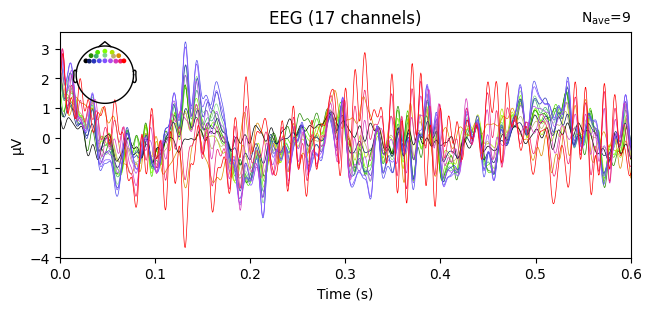

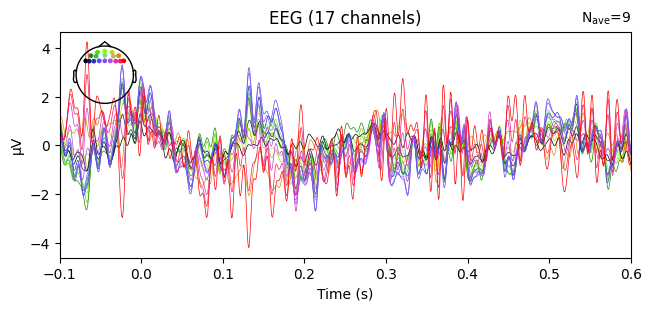

In [ ]:
trial_N = 0

kwargs_list = [
    dict(tmin=0,tmax=0.6,baseline=None),
    dict(tmin=-0.1,tmax=0.6,baseline=(None, 0)),
]
for kw in kwargs_list:
    trial_frp = sess.get_trial_frp(
        eeg_trial=eeg_trials[trial_N],
        et_trial=et_trials[trial_N],
        raw_behav=behav_trials,
        trial_N=trial_N,
        stim_scope="sequence",  # "sequence", "choices", or "both"
        selected_chans=c.EEG_CHAN_GROUPS.frontal,
        **kw,
    ).detrend()
    
    trial_frp_plot = plot_erp(trial_frp, 'mne', title=f'FRP - Trial {trial_N}')

In [ ]:
# fpath = ROOT / ".temp/sess_result.pkl"

sess_result = sess.analyze_session(
    save_dir=ROOT / "TEST_RES", preprocessed_dir=sess.preprocessed_dir
)
# save_pickle(sess_result, fpath)

def normalize_session_analysis_result(result):
    """Normalize legacy tuple outputs and current dict outputs to a Box."""
    if isinstance(result, Box):
        return result
    if isinstance(result, dict):
        return Box(result)

    (
        sess_frps,
        gaze_fixation_traces,
        eeg_fixation_epochs,
        stim_fixation_summary,
        fixation_events,
    ) = result
    return Box(
        dict(
            sess_frps=sess_frps,
            gaze_fixation_traces=gaze_fixation_traces,
            eeg_fixation_epochs=eeg_fixation_epochs,
            stim_fixation_summary=stim_fixation_summary,
            fixation_events=fixation_events,
        )
    )

# sess_result = normalize_session_analysis_result(read_file(fpath))

sess_frps = sess_result.sess_frps
gaze_fixation_traces = sess_result.gaze_fixation_traces
eeg_fixation_epochs = sess_result.eeg_fixation_epochs
stim_fixation_summary = sess_result.stim_fixation_summary
fixation_events = sess_result.fixation_events


AttributeError: 'dict' object has no attribute 'sess_frps'

In [13]:
sess_result = sess.analyze_session(
    save_dir=ROOT / "TEST_RES", preprocessed_dir=sess.preprocessed_dir
)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2680799
    Range : 0 ... 2680798 =      0.000 ...  1340.399 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Omitted 35 annotation(s) that were outside data range.
  raw.set_annotations(annotations)
/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Analyzing every trial:   0%|          | 0/80 [00:00<?, ?it/s]

In [16]:
sess_result = Box(sess_result)

In [13]:
stim_fixation_summary


,stim_ind,count,first_fix_order,total_duration,mean_duration,mean_pupil_diam,stim_name,trial_N,stim_type
0,2,2,3,0.2400,0.120000,6791.14,truck,0,sequence
1,3,2,2,0.1700,0.085000,6784.72,star,0,sequence
2,4,2,1,0.5520,0.276000,6758.28,star,0,sequence
3,5,2,4,0.4610,0.230500,6628.54,guitar,0,sequence
4,6,1,5,0.1100,0.110000,6541.36,truck,0,sequence
...,...,...,...,...,...,...,...,...,...
415,9,4,2,0.9495,0.237375,5675.66,heart,78,choice_correct
416,2,1,2,0.2380,0.238000,5506.27,hammer,79,sequence
417,3,2,1,0.4930,0.246500,5592.26,bulb,79,sequence
418,4,1,3,0.1920,0.192000,5736.02,eye,79,sequence


In [14]:
fixation_events


,fixation_N,stim_ind,onset,duration,pupil_diam,trial_N,stim_name,stim_type
0,0,4,0.254,0.205,6736.00,0,star,sequence
1,1,3,0.499,0.103,6662.54,0,star,sequence
2,2,2,0.641,0.125,6643.55,0,truck,sequence
3,3,5,1.109,0.238,6585.71,0,guitar,sequence
4,4,5,1.370,0.223,6671.37,0,guitar,sequence
...,...,...,...,...,...,...,...,...
742,0,3,0.329,0.147,5589.31,79,bulb,sequence
743,1,2,0.515,0.238,5506.27,79,hammer,sequence
744,2,3,0.795,0.346,5595.22,79,bulb,sequence
745,3,4,1.165,0.192,5736.02,79,eye,sequence


## Subj

In [ ]:
fpath = ROOT / ".temp/trials_data.pkl"

# trials_data = subj.get_trials_data(sess.preprocessed_dir)
# save_pickle(trials_data, fpath)
trials_data = read_file(fpath)

behav_trials, et_trials, eeg_trials = trials_data

Opening .pkl file...


Exception: Error reading file '/Users/chris/Documents/PhD-Local/abstract_reasoning/.temp/trials_data.pkl': Ran out of input

In [ ]:
assert len(set(map(len, [behav_trials, eeg_trials, et_trials]))) == 1

In [16]:
pd.DataFrame.from_dict(subj.get_sess_info()).T

,session_id,vision_correction,eye,eye_screen_dist,window_size,img_size,notes
1,ses-01,none,right,590,"2560, 1440","256, 256",
2,ses-02,none,right,610,"2560, 1440","256, 256",
3,ses-03,none,right,610,"2560, 1440","256, 256",
4,ses-04,none,right,610,"2560, 1440","256, 256",
5,ses-05,none,right,615,"2560, 1440","256, 256",


In [18]:
fpath = ROOT / ".temp/sess_results.pkl"

sess_results = subj.analyze_sessions(
    save_dir=ROOT / "TEST_RES", preprocessed_dir=sess.preprocessed_dir
)

save_pickle(sess_results, fpath)
# sess_results = read_file(fpath)

Analyzing subj 02 sessions:   0%|          | 0/5 [00:00<?, ?it/s]

Session trials: 0it [00:00, ?it/s]

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2680799
    Range : 0 ... 2680798 =      0.000 ...  1340.399 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Omitted 35 annotation(s) that were outside data range.
  raw.set_annotations(annotations)
/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2305357
    Range : 0 ... 2305356 =      0.000 ...  1152.678 secs
Ready.


...

/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Omitted 19 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2261351
    Range : 0 ... 2261350 =      0.000 ...  1130.675 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2255127
    Range : 0 ... 2255126 =      0.000 ...  1127.563 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:309: RuntimeWarning: Omitted 9 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


In [19]:
_sess_results = Box(subj._concat_session_analysis_results(sess_results))

In [20]:
_sess_results.gaze_target_fixation_sequence

,sess_N,fixation_N,stim_ind,onset,duration,pupil_diam,overall_trial_N,trial_N,stim_name,stim_type
0,1,0,4,0.254,0.205,6736.00,0,0,star,sequence
1,1,1,3,0.499,0.103,6662.54,0,0,star,sequence
2,1,2,2,0.641,0.125,6643.55,0,0,truck,sequence
3,1,3,5,1.109,0.238,6585.71,0,0,guitar,sequence
4,1,4,5,1.370,0.223,6671.37,0,0,guitar,sequence
...,...,...,...,...,...,...,...,...,...,...
2634,5,8,4,3.102,0.204,5126.83,399,79,guitar,sequence
2635,5,9,5,3.692,0.366,5111.72,399,79,key,sequence
2636,5,10,4,4.115,0.091,5130.48,399,79,guitar,sequence
2637,5,11,3,4.244,0.152,5142.16,399,79,helicopter,sequence


In [21]:
_sess_results.stim_fixation_summary


,sess_N,stim_ind,count,first_fix_order,total_duration,mean_duration,mean_pupil_diam,stim_name,overall_trial_N,trial_N,stim_type
0,1,2,2,3,0.240,0.120000,6791.14,truck,0,0,sequence
1,1,3,2,2,0.170,0.085000,6784.72,star,0,0,sequence
2,1,4,2,1,0.552,0.276000,6758.28,star,0,0,sequence
3,1,5,2,4,0.461,0.230500,6628.54,guitar,0,0,sequence
4,1,6,1,5,0.110,0.110000,6541.36,truck,0,0,sequence
...,...,...,...,...,...,...,...,...,...,...,...
1703,5,2,3,3,0.796,0.265333,5075.06,key,399,79,sequence
1704,5,3,2,4,0.283,0.141500,5142.94,helicopter,399,79,sequence
1705,5,4,5,1,0.837,0.167400,4954.66,guitar,399,79,sequence
1706,5,5,2,2,0.708,0.354000,4843.14,key,399,79,sequence


In [22]:
_sess_results.fixation_events


,sess_N,fixation_N,stim_ind,onset,duration,pupil_diam,overall_trial_N,trial_N,stim_name,stim_type
0,1,0,4,0.254,0.205,6736.00,0,0,star,sequence
1,1,1,3,0.499,0.103,6662.54,0,0,star,sequence
2,1,2,2,0.641,0.125,6643.55,0,0,truck,sequence
3,1,3,5,1.109,0.238,6585.71,0,0,guitar,sequence
4,1,4,5,1.370,0.223,6671.37,0,0,guitar,sequence
...,...,...,...,...,...,...,...,...,...,...
2634,5,8,4,3.102,0.204,5126.83,399,79,guitar,sequence
2635,5,9,5,3.692,0.366,5111.72,399,79,key,sequence
2636,5,10,4,4.115,0.091,5130.48,399,79,guitar,sequence
2637,5,11,3,4.244,0.152,5142.16,399,79,helicopter,sequence


In [23]:
_sess_results.fixation_events.groupby("overall_trial_N").count().iloc[:, 0].describe()


count    366.000000
mean       7.210383
std        5.266800
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       34.000000
Name: sess_N, dtype: float64

In [24]:
from contextlib import redirect_stdout
behav_df = subj.get_behav_data()

response_events = behav_df["solution_key"].unique().tolist()
print(f"{response_events = }")

selected_events = response_events  # ['trial_start']
selected_events = ["trial_start"]

with redirect_stdout(open(os.devnull, "w")):
    this_subj_erps = subj.get_erp(
        selected_events, tmin=-1.0, tmax=0.0, raw=False, erp_by_sess=True
    )


response_events = ['l', 'm', 'a', 'x']


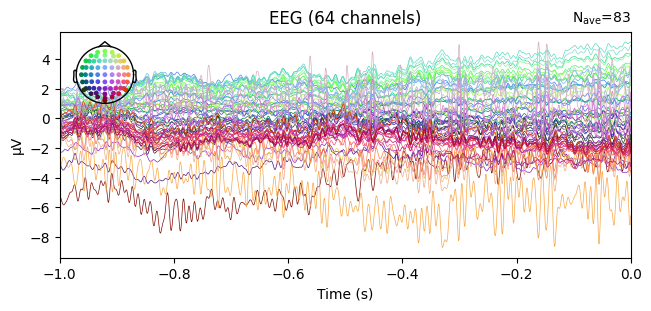

In [25]:
erp_plot = plot_erp(this_subj_erps[1], "mne")
erp_plot = plot_erp(this_subj_erps[1], "plotly", plotly_kwargs={"width":800, "height":450})


# EXPERIMENTS

In [26]:
def get_subj_pattern_erps(
    erp_events: list[str],
    *,
    erp_tmin: float = -0.6,
    erp_tmax: float = 0.0,
    epochs_name: str | None = None,
    selected_chans=list[str],
):
    """Return one frontal ERP per pattern for the requested event set."""
    if epochs_name is None:
        event_label = "_".join(erp_events)
        epochs_name = f"epochs_{event_label}"

    sess_epochs, behav_df, bad_sessions = subj.get_eeg_epochs(
        selected_chans=selected_chans,
        erp_events=erp_events,
        erp_tmin=erp_tmin,
        erp_tmax=erp_tmax,
        save_dir=None,
        preprocessed_dir=subj.preprocessed_dir,
        format="mne",
        trials_per_sess=80,
        epochs_name=epochs_name,
        combine=False,
    )
    pattern_inds = behav_df.groupby("pattern").groups

    combined_epochs = mne.concatenate_epochs(list(sess_epochs.values()))

    erp_per_pattern = {
        patt: combined_epochs[inds].average() for patt, inds in pattern_inds.items()
    }

    return erp_per_pattern


In [27]:
rest_erps = get_subj_pattern_erps(
    erp_events=["trial_start"],
    erp_tmin=-0.6,
    erp_tmax=0.0,
    epochs_name="epochs_rest_trial_start",
    selected_chans=c.EEG_CHAN_GROUPS.frontal,
)


response_erps = get_subj_pattern_erps(
    erp_events=["a", "x", "m", "l"],
    erp_tmin=-0.6,
    erp_tmax=0.0,
    epochs_name="epochs_response",
    selected_chans=c.EEG_CHAN_GROUPS.frontal,
)

Loading data for 83 events and 1230 original time points ...
0 bad epochs dropped
Removing practice trials from EEG data
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Not setting metadata
400 matching events found
No baseline correction applied


/var/folders/w9/5l3ld6f532s7q4xt6zb0x7sc0000gn/T/ipykernel_54013/3790048021.py:28: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epochs = mne.concatenate_epochs(list(sess_epochs.values()))


Loading data for 83 events and 1230 original time points ...
0 bad epochs dropped
Removing practice trials from EEG data
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 80 events and 1230 original time points ...
0 bad epochs dropped
Not setting metadata
400 matching events found
No baseline correction applied


/var/folders/w9/5l3ld6f532s7q4xt6zb0x7sc0000gn/T/ipykernel_54013/3790048021.py:28: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epochs = mne.concatenate_epochs(list(sess_epochs.values()))


In [28]:
behav_df = subj.get_behav_data()
pattern_inds = behav_df.groupby("pattern").groups

In [29]:
_sess_results.keys()
len([frp for frp in _sess_results.sess_frps.sequence])

400

In [30]:
# seq_frps = [frp for res in _sess_results.values() for frp in res.sess_frps.sequence]
seq_frps = [frp for frp in _sess_results.sess_frps.sequence]

_seq_frps = np.array(seq_frps)

seq_frps_by_patt = {patt:_seq_frps[inds] for patt, inds in pattern_inds.items()}

seq_frps_by_patt = {
    patt: mne.combine_evoked(
        [frp.pick(c.EEG_CHAN_GROUPS.frontal) for frp in frps if frp is not None],
        weights="equal",
    )
    for patt, frps in seq_frps_by_patt.items()
}

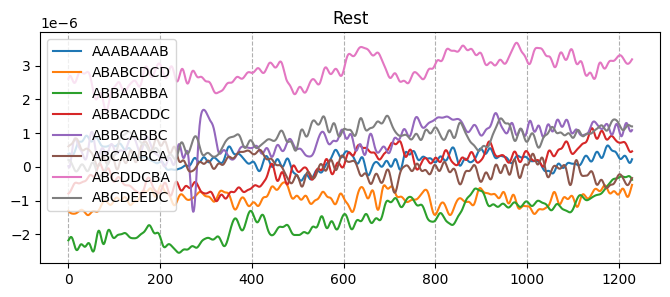

<Figure size 640x480 with 0 Axes>

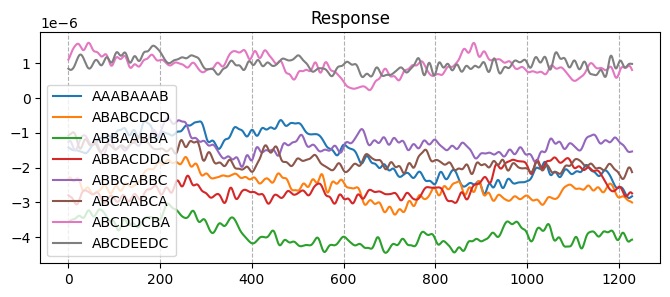

<Figure size 640x480 with 0 Axes>

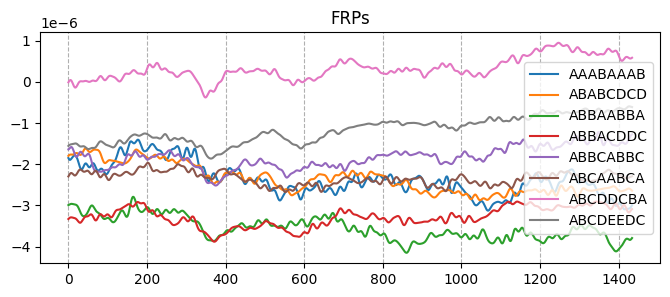

<Figure size 640x480 with 0 Axes>

In [31]:
def get_mean_trajectories(erps, title:str|None=None):
    mean_trajectories = {
        patt: erp.get_data().mean(axis=0) for patt, erp in erps.items()
    }

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(
        np.array([traj for traj in mean_trajectories.values()]).T,
        label=mean_trajectories.keys(),
    )
    ax.set_title(label='' if title is None else title)
    ax.legend()
    ax.grid(axis="x", ls="--")

    plt.show()
    plt.tight_layout()
    
    return mean_trajectories, fig


# fig, ax = plt.subplots()
# mne_kwargs=dict(axes=ax)

mean_traj_rest, mean_traj_rest_plot = get_mean_trajectories(rest_erps, title="Rest")
mean_traj_resp, mean_traj_resp_plot = get_mean_trajectories(
    response_erps, title="Response"
)
mean_traj_frp, mean_traj_frp_plot = get_mean_trajectories(
    seq_frps_by_patt, title="FRPs"
)


In [46]:
# rest_erps
# response_erps

d = np.array([frps.get_data().flatten() for frps in seq_frps_by_patt.values()])

d.shape

(8, 24395)

([<matplotlib.axis.YTick at 0x12f77a960>,
 [Text(0, 0, 'AAABAAAB'),
  Text(0, 1, 'ABABCDCD'),
  Text(0, 2, 'ABBAABBA'),
  Text(0, 3, 'ABBACDDC'),
  Text(0, 4, 'ABBCABBC'),
  Text(0, 5, 'ABCAABCA'),
  Text(0, 6, 'ABCDDCBA'),
  Text(0, 7, 'ABCDEEDC')])

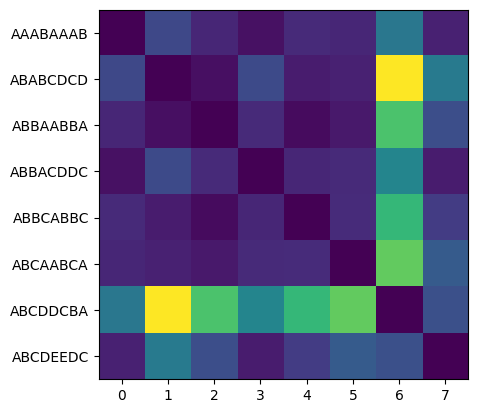

In [ ]:
# from rsatoolbox.rdm import RDMs
# from rsatoolbox.rdm import calc_rdm
# from rsatoolbox.data import Dataset

# ds = Dataset(measurements=d, obs_descriptors={"patterns": list(seq_frps_by_patt.keys())})
# rdm = calc_rdm(ds, method='correlation')

# plt.imshow(rdm.get_matrices().squeeze())
# plt.yticks(range(d.shape[0]), labels=list(ds.obs_descriptors['patterns']))

In [48]:
frp_mask = [0 if frp is None else 1 for frp in seq_frps]
# seq_frps.count(None)
behav_df["valid_frp"] = frp_mask
behav_df.groupby("pattern")["valid_frp"].sum()

NameError: name 'seq_frps' is not defined

In [44]:
behav_trials, et_trials, eeg_trials = subj.get_trials_data()

Loading subj 02 session trials:   0%|          | 0/5 [00:00<?, ?it/s]

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2680799
    Range : 0 ... 2680798 =      0.000 ...  1340.399 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 35 annotation(s) that were outside data range.
  raw.set_annotations(annotations)
/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2305357
    Range : 0 ... 2305356 =      0.000 ...  1152.678 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 14 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


...

/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 19 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2261351
    Range : 0 ... 2261350 =      0.000 ...  1130.675 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2255127
    Range : 0 ... 2255126 =      0.000 ...  1127.563 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/ar_analysis/data_loader/human/session.py:307: RuntimeWarning: Omitted 9 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


In [41]:
eeg_trials = list(eeg_trials)
et_trials = list(et_trials)

In [47]:
behav_df["valid_frp"]


NameError: name 'behav_df' is not defined